# Weight Estimation - Transfer Learning

**Author:** Xián Novoa Gutiérrez  
**Project:** Poultry Vision Monitoring  
**Repository:** https://github.com/xiannovoa/poultry-vision-monitoring

## Introduction

In this notebook, we further improve the chicken weight estimation model by introducing transfer learning techniques.

Previous experiments showed that, although the model benefits from data augmentation and architectural improvements, its performance is still limited (MAE ≈ 187 grams). This suggests that training a model from scratch may not fully exploit the available visual information.

To address this, we leverage a convolutional neural network pre-trained on a large-scale dataset (ImageNet) and adapt it to our regression task. This approach allows the model to reuse learned visual features and potentially improve generalization.

Additionally, we introduce a complementary evaluation metric based on relative error, motivated by the fact that the same absolute error does not have the same impact across different weight ranges.

All models will be evaluated using both MAE (in grams) and a relative error metric, enabling a more complete and fair comparison with previous approaches.

## 1. Dataset
https://huggingface.co/datasets/xiannovoa/poultry-weight-dataset

This part is identical to the previous notebooks.

In [1]:
from datasets import load_dataset, Image
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
ROOT = Path.cwd().resolve()

while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATASET_PATH = ROOT / "data/03_final/broiler_weight_dataset"

assert DATASET_PATH.exists(), f"Dataset no encontrado en {DATASET_PATH}"

In [3]:
dataset = load_dataset(
    "csv",
    data_files={"train": str(DATASET_PATH / "labels.csv")}
)

**Important**: The image paths in the CSV are relative (e.g., "images/img_00042.jpg").
We convert them to absolute paths so that the dataset can correctly load images from disk.

In [4]:
def add_full_path(example):
    example["image"] = str(DATASET_PATH / example["image"])
    return example

dataset = dataset.map(add_full_path)

In [5]:
dataset = dataset.cast_column("image", Image())

In [6]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'weight'],
        num_rows: 4761
    })
})


Weight: 1243


(np.float64(-0.5), np.float64(1839.5), np.float64(4079.5), np.float64(-0.5))

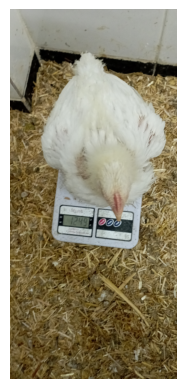

In [7]:
sample = dataset["train"][42]

print("Weight:", sample["weight"])

plt.imshow(sample["image"])
plt.axis("off")

## 2. Data Augmentation

This data augmentation strategy is reused from previous experiments (*02_weight_estimation_improvements*) to ensure consistency and isolate the impact of the model improvements.

In [8]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## 3. Data Preparation for Training (PyTorch)

We convert the dataset into a PyTorch-compatible format.

This includes:
- applying image transformations
- creating a custom Dataset
- preparing data for batching

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

### Custom PyTorch Dataset

We wrap our dataset into a Pytorch Dataset to:

- apply transformations
- return [image, weight] pairs

**Target normalization** is retained from previous experiments, as it proved essential for stabilizing training and improving performance.

Mean and standard deviation are computed on the training subset and used to normalize the target variable.

In [10]:
class NormalizedPoultryDataset(Dataset):
    def __init__(self, hf_dataset, transform=None, mean=0.0, std=1.0):
        self.dataset = hf_dataset
        self.transform = transform
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image = sample["image"]
        weight = sample["weight"]

        if weight is None:
            raise ValueError(f"Missing weight at index {idx}")

        if self.transform:
            image = self.transform(image)

        weight = (float(weight) - self.mean) / self.std
        weight = torch.tensor(weight, dtype=torch.float32)

        return image, weight

## 4. Train / Validation Split

The same data split and normalization strategy are maintained to ensure a fair comparison with previous models. The following cells and procedures are explained on previous notebooks (available on the repository).

In [11]:
from torch.utils.data import random_split

full_dataset = dataset["train"]

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

print(f"Train size: {len(train_subset)}")
print(f"Validation size: {len(val_subset)}")

Train size: 3808
Validation size: 953


In [12]:
import numpy as np

train_weights = [sample["weight"] for sample in train_subset]

mean_weight = np.mean(train_weights)
std_weight = np.std(train_weights)

print(f"Mean weight: {mean_weight:.2f}")
print(f"Std weight: {std_weight:.2f}")

Mean weight: 472.42
Std weight: 398.56


In [13]:
train_dataset = NormalizedPoultryDataset(
    train_subset,
    transform=train_transform, # With data augmentation
    mean=mean_weight,
    std=std_weight
)

val_dataset = NormalizedPoultryDataset(
    val_subset,
    transform=val_transform, # Without data augmentation
    mean=mean_weight,
    std=std_weight
)

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

## 5. Model (Transfer Learning)

We replace the custom CNN with a pre-trained convolutional neural network (**ResNet18**) to leverage learned visual features from large-scale datasets.

This approach allows the model to build upon previously learned representations, improving generalization and convergence speed.

To adapt the model to our regression task:

- the final classification layer is replaced with a single output neuron
- most of the network is frozen to retain pre-trained features
- only the final layers are trained

In [15]:
from torchvision import models
from torchvision.models import ResNet18_Weights
import torch.nn as nn

# Load pretrained ResNet18
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block (layer4)
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

# Replace final layer for regression
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

# Move to device
device = torch.device("cpu")
model = model.to(device)

## 6. Training with Validation (Transfer Learning)

We train the model using the same procedure as in previous experiments. However, since most layers are frozen, only the final layer is updated during training.

In [16]:
import torch.optim as optim

# Loss
criterion = nn.MSELoss()

# ONLY the trainable parameters
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

num_epochs = 30

for epoch in range(num_epochs):

    # TRAIN
    model.train()
    train_loss = 0.0

    for images, weights in train_loader:
        images = images.to(device)
        weights = weights.to(device)

        optimizer.zero_grad()

        outputs = model(images).squeeze()
        loss = criterion(outputs, weights)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, weights in val_loader:
            images = images.to(device)
            weights = weights.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, weights)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

Epoch [1/30] - Train Loss: 0.3188 - Val Loss: 0.1584
Epoch [2/30] - Train Loss: 0.1571 - Val Loss: 0.1163
Epoch [3/30] - Train Loss: 0.1395 - Val Loss: 0.0942
Epoch [4/30] - Train Loss: 0.1051 - Val Loss: 0.0763
Epoch [5/30] - Train Loss: 0.0775 - Val Loss: 0.0784
Epoch [6/30] - Train Loss: 0.0752 - Val Loss: 0.0774
Epoch [7/30] - Train Loss: 0.0746 - Val Loss: 0.0689
Epoch [8/30] - Train Loss: 0.0726 - Val Loss: 0.0632
Epoch [9/30] - Train Loss: 0.0621 - Val Loss: 0.0643
Epoch [10/30] - Train Loss: 0.0530 - Val Loss: 0.0700
Epoch [11/30] - Train Loss: 0.0577 - Val Loss: 0.0616
Epoch [12/30] - Train Loss: 0.0524 - Val Loss: 0.0788
Epoch [13/30] - Train Loss: 0.0479 - Val Loss: 0.0569
Epoch [14/30] - Train Loss: 0.0408 - Val Loss: 0.0474
Epoch [15/30] - Train Loss: 0.0365 - Val Loss: 0.0534
Epoch [16/30] - Train Loss: 0.0368 - Val Loss: 0.0528
Epoch [17/30] - Train Loss: 0.0327 - Val Loss: 0.0461
Epoch [18/30] - Train Loss: 0.0359 - Val Loss: 0.0497
Epoch [19/30] - Train Loss: 0.0324 - 

### Evaluation (MAE + Relative Error)

We evaluate the model using Mean Absolute Error (MAE) in grams, as well as a **relative error metric to better reflect performance across different weight ranges**.

The relative error is computed as the absolute error divided by the true weight, providing a percentage-based interpretation of the model’s accuracy.

In [17]:
model.eval()

mae = 0.0
relative_error = 0.0

with torch.no_grad():
    for images, weights in val_loader:
        images = images.to(device)
        weights = weights.to(device)

        outputs = model(images).squeeze()

        # Denormalize
        preds = outputs * std_weight + mean_weight
        targets = weights * std_weight + mean_weight

        # MAE
        mae += torch.abs(preds - targets).sum().item()

        # Relative error
        relative_error += (torch.abs(preds - targets) / targets).sum().item()

mae /= len(val_dataset)
relative_error /= len(val_dataset)

print(f"Validation MAE: {mae:.2f} grams")
print(f"Mean Relative Error: {relative_error:.4f} ({relative_error*100:.2f}%)")

Validation MAE: 50.22 grams
Mean Relative Error: 0.1386 (13.86%)


### Example Prediction

We visualize a prediction and compare it to the real weight.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

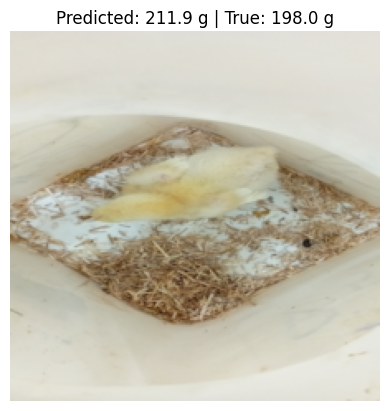

In [18]:
sample = val_dataset[0]

image, weight_norm = sample

model.eval()
with torch.no_grad():
    pred_norm = model(image.unsqueeze(0).to(device)).squeeze().cpu()

pred_weight = pred_norm.item() * std_weight + mean_weight
true_weight = weight_norm.item() * std_weight + mean_weight

img = image.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Predicted: {pred_weight:.1f} g | True: {true_weight:.1f} g")
plt.axis("off")

**The transfer learning approach with a pretrained ResNet18 shows a significant performance improvement over previous models**, reducing the MAE from approximately 187 grams to around 50 grams.

Fine-tuning the last layers of the network allows the model to adapt high-level visual features to the specific domain, leading to more accurate and consistent predictions across different weight ranges, as reflected in the reduced relative error.

Although the results are strong, some prediction errors still remain, suggesting that further improvements could be achieved by refining the data distribution, incorporating additional viewpoints, or exploring more advanced modeling strategies.